# 🐍 Python Level 1 - Introductory course
## Class 3 — Data Analysis with pandas

**Python instructor - Fábio Moreira and Luis Dias**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">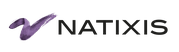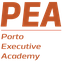</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | What is a DataFrame? |
| 2 | Loading a file, and the first look |
| 3 | Selecting columns and filtering rows |
| 4 | Data quality — missing values, duplicates, messy text |
| 5 | Creating and changing columns |
| 6 | Summarising — statistics, `groupby`, and tidying the result |
| 7 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Load a spreadsheet into Python and look around it
- Pick out the rows and columns you actually need
- Find and fix the usual problems in real data
- Answer a question with one line instead of a loop, and export the answer

---

> 💡 Last class you built a **list of dicts** by hand and said it was the shape of a
> spreadsheet. Today a library called **pandas** does that for you. It reads the file,
> holds the table, and gives you a method for every question you would otherwise write a
> loop for.

---
## 1. What is a DataFrame?

A **DataFrame** is a table: rows of data, with **named columns**. It is a spreadsheet that
you drive with code instead of with the mouse.

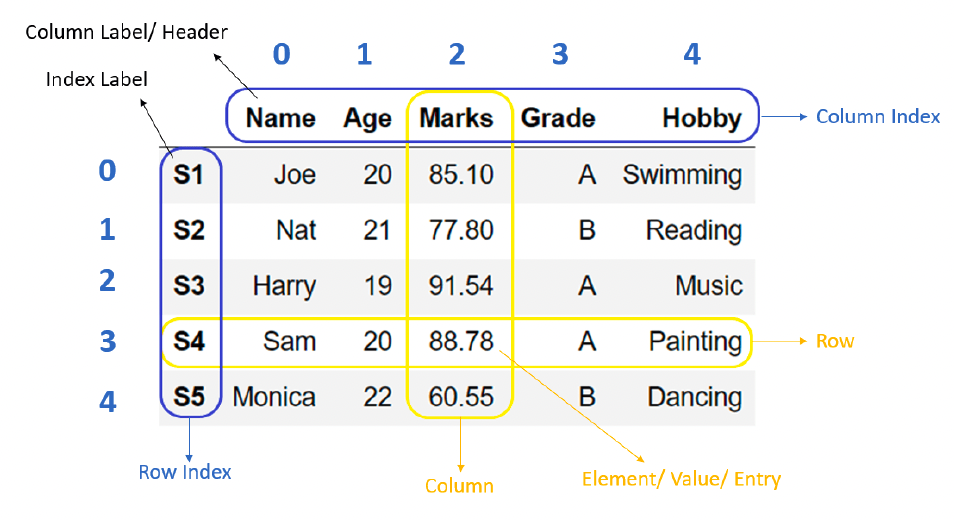

The file we will use is a monthly budget report. What each department planned to spend, and
what it actually spent:

| department | category | month | budget | actual |
|------------|----------|-------|--------|--------|
| Operations | Travel | 2026-01 | 7500 | 7307.02 |
| Operations | Software | 2026-01 | 9500 | 10552.53 |
| Operations | Training | 2026-01 | 17000 | 20052.32 |
| … | … | … | … | … |

Two words worth knowing straight away:

| Term | What it is |
|------|-----------|
| **DataFrame** | the whole table — many columns |
| **Series** | a single column, on its own |

So `expenses` is a DataFrame, and `expenses["budget"]` is a Series.

### Why not just a list of dicts?

You could do all of today's work with the loops you already know. pandas is worth learning
because it turns each of those loops into **one line**:

| The question | With loops | With pandas |
|--------------|-----------|-------------|
| Total spend | a loop and a running total | `expenses["actual"].sum()` |
| Only the overspends | a loop and an `if` | `expenses[expenses["actual"] > expenses["budget"]]` |
| Total per department | a dict, a loop, `.append()` | `expenses.groupby("department")["actual"].sum()` |

And it reads a CSV file for you, which is where real data lives.

---
## 2. Loading a file, and the first look

pandas is a **library** — someone else's code that you borrow. You bring it in with `import`,
and everyone writes it the same way:

```
import pandas as pd
```

`as pd` gives it a short nickname, so you type `pd.read_csv(...)` instead of
`pandas.read_csv(...)`. You will see `pd` in every pandas example ever written.

### Getting the file to Colab

Colab runs on Google's computers, not yours, so it **cannot see your files**. The usual way
round this is to put the file in your **Google Colab** files space.

### The first four things to run

Every time you open a new file, ask it these four questions:

| Question | Method |
|----------|--------|
| How big is it? | `expenses.shape` → `(rows, columns)` |
| What does it look like? | `expenses.head()` — the first 5 rows |
| What are the columns called? | `expenses.columns` |
| What is in them, and what is missing? | `expenses.info()` |

`expenses.describe()` adds count, mean, min and max for every number column at once.

> 💡 In a notebook, the **last line of a cell displays by itself** — that is why
> `expenses.head()` shows a table with no `print()` around it.

In [ ]:
import pandas as pd

# Put expenses.csv in your Google Colab folder space first, then run this cell and allow access.
CSV_PATH = "expenses.csv"
expenses = pd.read_csv(CSV_PATH)

print(expenses.shape)
# (154, 6) - 154 rows, 6 columns

In [ ]:
print(expenses.columns)      # the column names

In [ ]:
expenses.info()              # types and missing counts - info() prints by itself

In [ ]:
print(expenses.describe())   # count/mean/min/max for the number columns

In [ ]:
expenses.head()  # the first 5 rows, shown as a table

---
## 3. Selecting columns and filtering rows

### Columns

| What you want | How | You get |
|---------------|-----|---------|
| One column | `expenses["budget"]` | a **Series** |
| Several columns | `expenses[["department", "budget"]]` | a **DataFrame** |

> ⚠️ Several columns needs **two** pairs of brackets. The inner pair is the *list* of names
> you want; the outer pair is the selection. `expenses["department", "budget"]` is an error.

### Rows — filtering with a condition

`expenses["budget"] > 30000` gives you a column of `True`/`False`, one per row. Put that
inside `expenses[...]` and you keep only the `True` rows:

```
big = expenses[expenses["budget"] > 30000]
```

Read it inside out: *"the rows of expenses where the budget is over 30000"*.

| Combining conditions | Write |
|----------------------|-------|
| Both must hold | `expenses[(A) & (B)]` |
| Either will do | `expenses[(A) \| (B)]` |
| Value is one of a list | `expenses[expenses["category"].isin(["Travel", "Office"])]` |

> ⚠️ Two traps here. Use `&` and `|`, **not** `and` / `or`, when filtering a DataFrame. And
> wrap each condition in **its own brackets** — `(A) & (B)`, never `A & B`.

In [ ]:
# One column is a Series
print(expenses["budget"].head())
print(type(expenses["budget"]))

In [ ]:
# Several columns need two pairs of brackets
print(expenses[["department", "budget"]].head())

In [ ]:
# Filtering: keep only the rows where the condition is True
big = expenses[expenses["budget"] > 30000]
print("Rows with a budget over 30000:", len(big))

In [ ]:
# Both conditions must hold - note the brackets around each one, and the &
big_travel = expenses[(expenses["budget"] > 30000) & (expenses["category"] == "Travel")]
print("...and in Travel:", len(big_travel))

In [ ]:
# .isin() saves a long chain of == joined by |
two = expenses[expenses["category"].isin(["Travel", "Office"])]
print("Travel or Office rows:", len(two))

---
## 4. Data quality — missing values, duplicates, messy text

Real files are never clean. Fix them **before** you calculate anything, or every number you
produce afterwards is wrong. Four problems cover almost every case:

### Missing values

A blank cell in the file becomes `NaN` — *not a number*. `.isnull()` marks each one `True`, so
`.isnull().sum()` counts them per column.

Then choose, and the choice matters:

| You want | Method | When |
|----------|--------|------|
| Remove those rows | `.dropna(subset=["actual"])` | the row is useless without that value |
| Fill them in | `.fillna(0)` | a sensible stand-in exists |

### Duplicate rows

`.drop_duplicates()` removes rows that are identical to an earlier one. Compare `.shape`
before and after to see how many went.

### Messy text

The same department is written `Finance`, `finance` and `FINANCE` — three different values as
far as Python is concerned, which would split your totals three ways. `.str.lower()` puts a
whole text column into lower case. `.replace()` swaps one specific value for another.

### Columns you don't need

`.drop(columns=["notes"])` removes them. Fewer columns, less to read.

> ⚠️ These methods hand you back a **new** table and leave the original alone. To keep the
> result you must assign it: `expenses = expenses.drop_duplicates()`. Forgetting the
> assignment is the most common pandas mistake there is.

In [ ]:
# 1. What is missing, and where?
print(expenses.isnull().sum())

In [ ]:
# 2. Duplicate rows - compare the shape before and after
print("before:", expenses.shape)
expenses = expenses.drop_duplicates()
print("after :", expenses.shape)

In [ ]:
# 3. Messy text - three spellings of the same department
print(sorted(expenses["department"].unique()))
expenses["department"] = expenses["department"].str.lower()
print(sorted(expenses["department"].unique()))

In [ ]:
# 4. A column that holds nothing useful
expenses = expenses.drop(columns=["notes"])

In [ ]:
# 5. Rows with no actual spend tell us nothing - remove them
expenses = expenses.dropna(subset=["actual"])
print("clean :", expenses.shape)

---
## 5. Creating and changing columns

A new column is made by naming it on the left and giving a recipe on the right. The recipe is
applied to **every row at once** — no loop.

| What you want | How |
|---------------|-----|
| Arithmetic between columns | `expenses["difference"] = expenses["actual"] - expenses["budget"]` |
| A True/False flag | `expenses["over_budget"] = expenses["actual"] > expenses["budget"]` |
| Round a column | `expenses["difference"] = expenses["difference"].round(2)` |
| Swap a specific value | `expenses["category"] = expenses["category"].replace("Office", "Office supplies")` |

That third one is worth pausing on: `expenses["actual"] > expenses["budget"]` compares the two
columns row by row and hands back a whole column of `True`/`False`. A single comparison, 141
answers.

In [ ]:
# Arithmetic between two columns, applied to every row at once
expenses["difference"] = expenses["actual"] - expenses["budget"]
expenses["difference"] = expenses["difference"].round(2)

In [ ]:
# A True/False column from a comparison
expenses["over_budget"] = expenses["actual"] > expenses["budget"]

In [ ]:
# Swap one specific value for a clearer one
expenses["category"] = expenses["category"].replace("Office", "Office supplies")

print(expenses[["department", "category", "budget", "actual", "difference", "over_budget"]].head())

In [ ]:
# True counts as 1, so summing a True/False column counts the Trues
print("Lines over budget:", expenses["over_budget"].sum())

---
## 6. Summarising — statistics, `groupby`, and tidying the result

### One number out of a column

| Method | Gives |
|--------|-------|
| `.sum()` | the total |
| `.mean()` | the average |
| `.min()` / `.max()` | smallest / largest |
| `.round(2)` | rounded, for printing |

### What values are in a column

| Method | Gives |
|--------|-------|
| `.unique()` | each different value, once |
| `.nunique()` | **how many** different values |
| `.value_counts()` | each value and how often it appears |

### `groupby` — the same statistic, per group

This is the one that replaces a dict, a loop and an `if`. Read it left to right:

```
expenses.groupby("department")["actual"].sum()
                  │             │        │
                  │             │        └── and total it
                  │             └── this column
                  └── split into groups
```

### Tidying the result

A `groupby` result is sorted by group name and has the group as its index. Three methods make
it presentable:

| Method | Does |
|--------|------|
| `.sort_values(ascending=False)` | biggest first |
| `.reset_index()` | turn the index back into a normal column |
| `.rename(columns={"actual": "total_spend"})` | give a column a clearer name |

In [ ]:
# One number out of a column
print("Total budget :", expenses["budget"].sum())
print("Total actual :", round(expenses["actual"].sum(), 2))
print("Average spend:", round(expenses["actual"].mean(), 2))
print("Biggest line :", expenses["actual"].max())

In [ ]:
# What is in a column
print("Departments  :", expenses["department"].nunique())
print(expenses["category"].value_counts())

In [ ]:
# groupby: the same statistic, once per group
by_department = expenses.groupby("department")["actual"].sum().round(2)
print(by_department)

In [ ]:
# Biggest spender first
print(by_department.sort_values(ascending=False))

In [ ]:
# Turn it into a tidy table with proper column names
summary = by_department.reset_index()
summary = summary.rename(columns={"actual": "total_spend"})
print(summary)

---
## 7. 🔗 Putting it all together — monthly expenses report

Everything from today, as the job it actually is.

### The situation

The finance team sends you a file of budget-versus-actual spend each month. They want a short
report: which departments overspent, by how much, and a clean file they can open in Excel.
The raw file has the usual problems — duplicated rows, blank values, and the same department
spelled three different ways.

### The pipeline

```
   expenses.csv
        │
        ▼
   read_csv()               load
        │
        ▼
   drop_duplicates()        clean
   str.lower()
   dropna()
        │
        ▼
   difference, over_budget  derive
        │
        ▼
   over_budget == True      filter
        │
        ▼
   groupby("department")    summarise
        │
        ▼
   to_csv()                 export
```

### What the program must do

1. **Load** the file and report its size
2. **Clean** it — drop duplicates, lower-case the department, drop the empty column, and
   remove rows with no actual spend
3. **Derive** two new columns: the difference, and whether the line went over budget
4. **Filter** to the overspending lines only
5. **Summarise** — total overspend per department, biggest first
6. **Export** the summary to a CSV file the team can open

In [ ]:
# Let's go through a possible solution.

In [ ]:
# @title
# ── 1. LOAD ────────────────────────────────────────────────────────────────
report = pd.read_csv(CSV_PATH)
print("loaded :", report.shape)

# ── 2. CLEAN ───────────────────────────────────────────────────────────────
report = report.drop_duplicates()
report["department"] = report["department"].str.lower()
report = report.drop(columns=["notes"])
report = report.dropna(subset=["actual"])
print("cleaned:", report.shape)

# ── 3. DERIVE ──────────────────────────────────────────────────────────────
report["difference"] = (report["actual"] - report["budget"]).round(2)
report["over_budget"] = report["actual"] > report["budget"]

# ── 4. FILTER ──────────────────────────────────────────────────────────────
overspends = report[report["over_budget"] == True]
print("over budget:", len(overspends), "lines")

# ── 5. SUMMARISE ───────────────────────────────────────────────────────────
by_department = overspends.groupby("department")["difference"].sum().round(2)
by_department = by_department.sort_values(ascending=False)

summary = by_department.reset_index()
summary = summary.rename(columns={"difference": "total_overspend"})

print()
print("OVERSPEND BY DEPARTMENT")
print(summary)

# ── 6. EXPORT ──────────────────────────────────────────────────────────────
summary.to_csv("overspend_summary.csv", index=False)
print()
print("Saved overspend_summary.csv")

---

### 🎉 That's Level 1 Class 3!

| Concept | Key syntax |
|---------|-----------|
| Bring in pandas | `import pandas as pd` |
| Read a file | `pd.read_csv(path)` |
| Size | `expenses.shape` |
| First rows | `expenses.head()` |
| Column names | `expenses.columns` |
| Types and missing | `expenses.info()` |
| Number summary | `expenses.describe()` |
| One column (a Series) | `expenses["budget"]` |
| Several columns | `expenses[["a", "b"]]` |
| Filter rows | `expenses[expenses["budget"] > 30000]` |
| Combine conditions | `(A) & (B)`, `(A) \| (B)` |
| Value in a list | `.isin(["Travel", "Office"])` |
| Count missing | `.isnull().sum()` |
| Drop / fill missing | `.dropna(subset=[...])`, `.fillna(0)` |
| Remove duplicates | `.drop_duplicates()` |
| Remove columns | `.drop(columns=[...])` |
| Tidy text | `.str.lower()`, `.replace(old, new)` |
| New column | `expenses["new"] = ...` |
| Statistics | `.sum()`, `.mean()`, `.min()`, `.max()`, `.round(2)` |
| Values in a column | `.unique()`, `.nunique()`, `.value_counts()` |
| Per group | `.groupby("col")["other"].sum()` |
| Tidy a result | `.sort_values()`, `.reset_index()`, `.rename(columns=...)` |
| Save a file | `.to_csv("name.csv", index=False)` |

> ⚠️ The one to remember: these methods return a **new** table. `expenses.dropna()` on its own
> changes nothing — you need `expenses = expenses.dropna()`.

➡️ Now open the **exercises notebook**.